In [4]:
pip install amplpy matplotlib pandas numpy seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 27.3 MB/s eta 0:00:00


In [5]:
from amplpy import AMPL, ampl_notebook
ampl = ampl_notebook(
    modules=["highs", "gurobi", "xpress", "cplex"], # pick from over 20 modules including most commercial and open-source solvers
    license_uuid="2b02ed43-e5a1-40b0-ba3f-485b7a228e11") # your license UUID (e.g., free ampl.com/ce or ampl.com/courses licenses)

Licensed to AMPL Personal Prototyping License for <ramyyyyaaaa1109@gmail.com>.


In [6]:
try:
    test_ampl = AMPL()
    test_ampl.eval('option version;') # Checks AMPL version and license status
    test_ampl.eval('option solver highs;') # Verifies HiGHS is set as the default solver and is accessible
    print("AMPL executable and HiGHS solver found and initialized successfully via amplpy.")
    test_ampl.close() # Closes the temporary AMPL instance
except Exception as e:
    # Provides detailed instructions for troubleshooting if initialization fails
    raise RuntimeError(f"Failed to initialize AMPL after setup: {e}. "
                       f"Please ensure 'YOUR-UUID-HERE' is replaced with a valid license "
                       f"and inspect the amplpy installation status manually at {ampl_root_dir}.") from e

print("AMPL environment fully set up and ready for use.")


option version 'AMPL Version 20250901 (Linux-6.8.0-1031-azure, 64-bit)\
Licensed to AMPL Personal Prototyping License for <ramyyyyaaaa1109@gmail.com>.\
Temporary license expires 20260530.\
Using license file "/usr/local/lib/python3.12/dist-packages/ampl_module_base/bin/ampl.lic".\
';
AMPL executable and HiGHS solver found and initialized successfully via amplpy.
AMPL environment fully set up and ready for use.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

In [8]:
flights_df = pd.read_csv('https://raw.githubusercontent.com/Gurobi/modeling-examples/master/aviation_planning/data/flight_rotations_2006-07-01.csv')


In [9]:
flights_df.head()

,flight,date,aircraft,ori,des,start_time,end_time,duration
0,1,7/1/06,TranspCom#1,CDG,ORY,0:00,0:30,0:30
1,73,7/1/06,TranspCom#3,ORY,CDG,0:00,0:30,0:30
2,2,7/1/06,TranspCom#2,CDG,ORY,0:20,0:50,0:30
3,74,7/1/06,TranspCom#4,ORY,CDG,0:20,0:50,0:30
4,75,7/1/06,TranspCom#1,ORY,CDG,0:40,1:10,0:30


In [10]:
df_filtered = flights_df[flights_df["aircraft"] == "TranspCom#1"]

print(df_filtered)

     flight    date     aircraft  ori  des start_time end_time duration
0         1  7/1/06  TranspCom#1  CDG  ORY       0:00     0:30     0:30
4        75  7/1/06  TranspCom#1  ORY  CDG       0:40     1:10     0:30
8         5  7/1/06  TranspCom#1  CDG  ORY       1:20     1:50     0:30
12       79  7/1/06  TranspCom#1  ORY  CDG       2:00     2:30     0:30
16        9  7/1/06  TranspCom#1  CDG  ORY       2:40     3:10     0:30
20       83  7/1/06  TranspCom#1  ORY  CDG       3:20     3:50     0:30
24       13  7/1/06  TranspCom#1  CDG  ORY       4:00     4:30     0:30
28       87  7/1/06  TranspCom#1  ORY  CDG       4:40     5:10     0:30
34       17  7/1/06  TranspCom#1  CDG  ORY       5:20     5:50     0:30
79       91  7/1/06  TranspCom#1  ORY  CDG       6:00     6:30     0:30
103      21  7/1/06  TranspCom#1  CDG  ORY       6:40     7:10     0:30
116      95  7/1/06  TranspCom#1  ORY  CDG       7:20     7:50     0:30
154      25  7/1/06  TranspCom#1  CDG  ORY       8:00     8:30  

In [11]:
df_iterinaries = pd.read_csv('https://raw.githubusercontent.com/Gurobi/modeling-examples/master/aviation_planning/data/flight_iterinaries.csv')
df_iterinaries['total_cost'] = df_iterinaries['cost']*df_iterinaries['n_pass']
flight_revenue = df_iterinaries.groupby(['flight'])['total_cost'].agg('sum').to_dict()
flight_n_pass = df_iterinaries.groupby(['flight'])['n_pass'].agg('sum').to_dict()

In [12]:
df_iterinaries.head()

,cost,n_pass,flight,total_cost
0,137.5,24.0,4296.0,3300.0
1,137.5,33.0,4296.0,4537.5
2,137.5,24.0,4296.0,3300.0
3,137.5,44.0,4296.0,6050.0
4,137.5,35.0,4295.0,4812.5


In [13]:
df_revenue=pd.DataFrame.from_dict(flight_revenue, orient='index', columns=['total_revenue'])

df_revenue.index.name ='flight'

df_revenue=df_revenue.reset_index()

df_pass=pd.DataFrame.from_dict(flight_n_pass, orient='index', columns=['total_passengers'])

df_pass.index.name ='flight'

df_pass=df_pass.reset_index()


In [14]:
df_merged=flights_df.merge(df_revenue, on='flight', how='left').merge(df_pass, on='flight', how='left')



In [15]:
df_merged.head()

,flight,date,aircraft,ori,des,start_time,end_time,duration,total_revenue,total_passengers
0,1,7/1/06,TranspCom#1,CDG,ORY,0:00,0:30,0:30,NaN,NaN
1,73,7/1/06,TranspCom#3,ORY,CDG,0:00,0:30,0:30,NaN,NaN
2,2,7/1/06,TranspCom#2,CDG,ORY,0:20,0:50,0:30,NaN,NaN
3,74,7/1/06,TranspCom#4,ORY,CDG,0:20,0:50,0:30,NaN,NaN
4,75,7/1/06,TranspCom#1,ORY,CDG,0:40,1:10,0:30,NaN,NaN


In [16]:
df_merged.fillna(0, inplace=True)

In [17]:
df_merged.head()

,flight,date,aircraft,ori,des,start_time,end_time,duration,total_revenue,total_passengers
0,1,7/1/06,TranspCom#1,CDG,ORY,0:00,0:30,0:30,0.0,0.0
1,73,7/1/06,TranspCom#3,ORY,CDG,0:00,0:30,0:30,0.0,0.0
2,2,7/1/06,TranspCom#2,CDG,ORY,0:20,0:50,0:30,0.0,0.0
3,74,7/1/06,TranspCom#4,ORY,CDG,0:20,0:50,0:30,0.0,0.0
4,75,7/1/06,TranspCom#1,ORY,CDG,0:40,1:10,0:30,0.0,0.0


In [18]:
df_merged = df_merged.rename(columns={
    'flight': 'flight_id',
    'cost': 'cancel_cost', # Original 'cost' column represents cancellation cost
    'start_time': 'dep_time',
    'end_time': 'arr_time',
    'ori': 'origin',
    'des': 'destination'
})

In [19]:
def time_to_minutes(time_str):
    if pd.isna(time_str):
        return None
    hours, minutes = map(int, time_str.split(':'))
    return hours * 60 + minutes
  # Apply the time conversion to departure and arrival time columns.
df_merged['dep_time'] = df_merged['dep_time'].apply(time_to_minutes)
df_merged['arr_time'] = df_merged['arr_time'].apply(time_to_minutes)
df_merged['duration'] = df_merged['duration'].apply(time_to_minutes)
print(f"Total flights scheduled (reloaded): {len(df_merged)}")

Total flights scheduled (reloaded): 608


In [20]:
df_merged.head()

,flight_id,date,aircraft,origin,destination,dep_time,arr_time,duration,total_revenue,total_passengers
0,1,7/1/06,TranspCom#1,CDG,ORY,0,30,30,0.0,0.0
1,73,7/1/06,TranspCom#3,ORY,CDG,0,30,30,0.0,0.0
2,2,7/1/06,TranspCom#2,CDG,ORY,20,50,30,0.0,0.0
3,74,7/1/06,TranspCom#4,ORY,CDG,20,50,30,0.0,0.0
4,75,7/1/06,TranspCom#1,ORY,CDG,40,70,30,0.0,0.0


In [21]:
flights = df_merged['flight_id'].unique() # Used for AMPL sets and iterations
aircrafts = df_merged['aircraft'].unique() # Used for AMPL sets
airports = sorted(list(set(df_merged['origin'].unique()) | set(df_merged['destination'].unique()))) # All unique airports in the flight network
print(f"{len(flights)} flights between {len(airports)} airports operated with {len(aircrafts)} aircrafts (redefined)")

608 flights between 35 airports operated with 85 aircrafts (redefined)


In [22]:
ampl_model = """

# ---------------------------------------------------------------------------
# SETS
# ---------------------------------------------------------------------------

set FLIGHTS;                           # All flight IDs
set AIRPORTS;                          # All airport codes
set AIRCRAFT;                          # All aircraft tail numbers

# LEGS: feasible flight-to-flight transitions (same aircraft,
#        dest[i]=origin[j], arr_time[i] + turnaround <= dep_time[j])
set LEGS within FLIGHTS cross FLIGHTS;

# ---------------------------------------------------------------------------
# PARAMETERS
# ---------------------------------------------------------------------------

param dep_time   {i in FLIGHTS} >= 0;       # Departure time (mins from 00:00)
param arr_time   {i in FLIGHTS} >= 0;       # Arrival time   (mins from 00:00)
param duration   {i in FLIGHTS} >= 0;       # Block time     (mins)
param origin     {i in FLIGHTS} symbolic;   # Origin airport
param dest       {i in FLIGHTS} symbolic;   # Destination airport
param aircraft0  {i in FLIGHTS} symbolic;   # Originally assigned aircraft
param revenue    {i in FLIGHTS} >= 0;       # Passenger revenue (€)
param pax        {i in FLIGHTS} >= 0;       # Total passengers

# alpha: fraction of flights airports CAN handle (1=normal, 0=full shutdown)
# Per the brief: alpha=0.5 means airports operate at 50% capacity
param alpha >= 0, <= 1 default 0.5;

param turnaround default 30;   # Minimum turnaround time (mins)
param EOD        default 1440; # End of day (24*60 mins)

# Total departures/arrivals per airport in the undisrupted plan
param total_dep {i in AIRPORTS} >= 0;
param total_arr {i in AIRPORTS} >= 0;

# ---------------------------------------------------------------------------
# DECISION VARIABLE
# ---------------------------------------------------------------------------

# operate[i] = 1 → flight i is flown, 0 → cancelled
var operate {i in FLIGHTS} binary;

# ---------------------------------------------------------------------------
# OBJECTIVE: Maximise retained revenue
# ---------------------------------------------------------------------------

maximize RetainedRevenue:
    sum {i in FLIGHTS} revenue[i] * operate[i];

# ---------------------------------------------------------------------------
# CONSTRAINTS
# ---------------------------------------------------------------------------

# C1: Airport departure capacity
subject to DepartureCap {p in AIRPORTS}:
    sum {i in FLIGHTS : origin[i] = p} operate[i] <= (1 - alpha) * total_dep[p];

# C2: Airport arrival capacity
subject to ArrivalCap {p in AIRPORTS}:
    sum {i in FLIGHTS : dest[i] = p} operate[i] <= (1 - alpha) * total_arr[p];

# C3: Aircraft non-overlap — two flights on same aircraft cannot clash in time
subject to NoOverlap {i in FLIGHTS, j in FLIGHTS
    : i < j
    and aircraft0[i] = aircraft0[j]
    and arr_time[i] + turnaround > dep_time[j]
    and arr_time[j] + turnaround > dep_time[i]}:
    operate[i] + operate[j] <= 1;

# C4: If a flight operates, it needs a valid predecessor OR is the first flight
#     of the day for that aircraft (no predecessor exists in LEGS)
subject to AircraftContinuity {j in FLIGHTS
    : exists {(i,j2) in LEGS : j2 = j} 1}:
    operate[j] <= sum {(i,j2) in LEGS : j2 = j} operate[i];

# C5: End of day — flights arriving after midnight cannot operate
subject to EODFeasibility {i in FLIGHTS : arr_time[i] > EOD}:
    operate[i] = 0;

"""

In [23]:
#Build per-airport departure/arrival counts
flight_data = df_merged.set_index('flight_id')

total_dep = df_merged.groupby('origin')['flight_id'].count().to_dict()
total_arr = df_merged.groupby('destination')['flight_id'].count().to_dict()

#Adding Legs and Turn-around for each flights
TURNAROUND = 30
legs = []
for ac, grp in flight_data.groupby('aircraft'):
    grp_flights = grp.index.tolist()
    for i in grp_flights:
        for j in grp_flights:
            if i != j:
                if (flight_data.loc[i, 'destination'] == flight_data.loc[j, 'origin'] and
                        flight_data.loc[i, 'arr_time'] + TURNAROUND <= flight_data.loc[j, 'dep_time']):
                    legs.append((i, j))


In [24]:

#Solution Function
def execute(alpha):
    ampl.reset()
    ampl.eval(ampl_model)

    # Sets
    ampl.set['FLIGHTS']  = flights.tolist()
    ampl.set['AIRPORTS'] = airports
    ampl.set['AIRCRAFT'] = aircrafts.tolist()
    ampl.set['LEGS']     = legs

    # Scalar parameters
    ampl.param['alpha']      = alpha
    ampl.param['turnaround'] = 30
    ampl.param['EOD']        = 1440

    # Per-airport capacity parameters
    ampl.param['total_dep'] = total_dep
    ampl.param['total_arr'] = total_arr

    # Flight parameters
    ampl.param['dep_time']  = flight_data['dep_time'].to_dict()
    ampl.param['arr_time']  = flight_data['arr_time'].to_dict()
    ampl.param['duration']  = flight_data['duration'].to_dict()
    ampl.param['revenue']   = flight_data['total_revenue'].to_dict()
    ampl.param['pax']       = flight_data['total_passengers'].to_dict()
    ampl.param['origin']    = flight_data['origin'].to_dict()
    ampl.param['dest']      = flight_data['destination'].to_dict()
    ampl.param['aircraft0'] = flight_data['aircraft'].to_dict()

    # Solving using Highs model
    ampl.option['solver'] = 'highs'
    ampl.solve()

    solve_result = ampl.get_value('solve_result')
    obj_value    = ampl.get_value('RetainedRevenue')

    operate_df = ampl.var['operate'].to_pandas()
    operate_df.columns = ['operate']
    operated_flights  = operate_df[operate_df['operate'] > 0.5].index.tolist()
    cancelled_flights = operate_df[operate_df['operate'] < 0.5].index.tolist()

    print(f"alpha={alpha:.2f} | Status: {solve_result} | "
          f"Retained Revenue: €{obj_value:,.0f} | "
          f"Operated: {len(operated_flights)} | Cancelled: {len(cancelled_flights)}")

    return {
        'alpha':            alpha,
        'solve_result':     solve_result,
        'retained_revenue': obj_value,
        'n_operated':       len(operated_flights),
        'n_cancelled':      len(cancelled_flights),
        'operated_flights': operated_flights,
        'cancelled_flights':cancelled_flights,
    }


In [25]:
# ---------------------------------------------------------------------------
# Base case: alpha = 0.5
# ---------------------------------------------------------------------------
print("=== BASE CASE: alpha = 0.5 ===")
base_result = execute(0.5)


=== BASE CASE: alpha = 0.5 ===
HiGHS 1.11.0: HiGHS 1.11.0: optimal solution; objective 6921639.4
208 simplex iterations
1 branching nodes
alpha=0.50 | Status: solved | Retained Revenue: €6,921,639 | Operated: 242 | Cancelled: 366


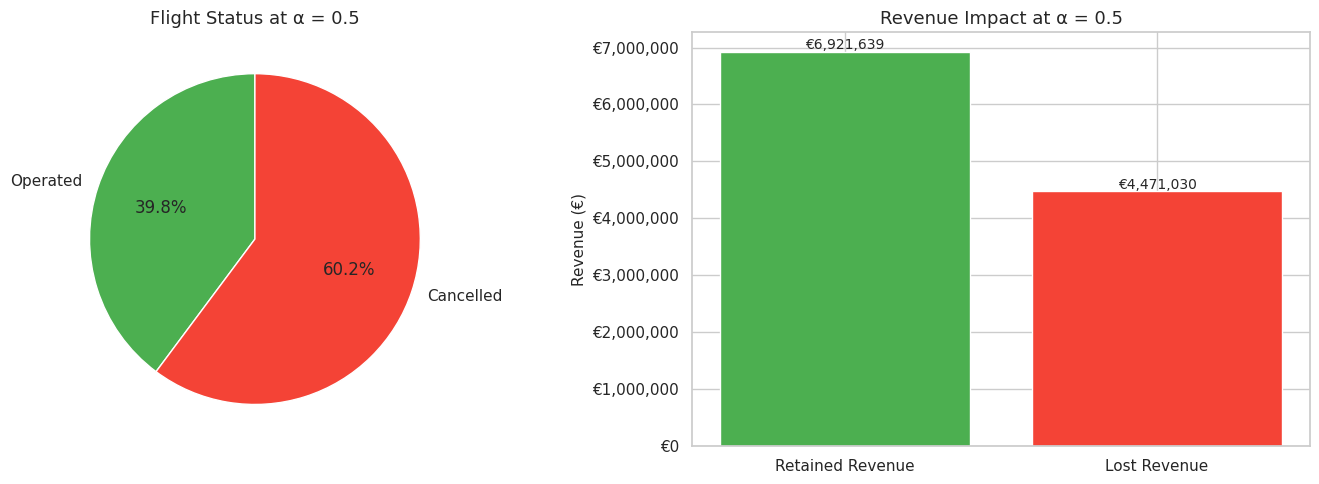

In [26]:
labels = ['Operated', 'Cancelled']
sizes  = [base_result['n_operated'], base_result['n_cancelled']]
colors = ['#4CAF50', '#F44336']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
axes[0].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Flight Status at α = 0.5', fontsize=13)

# --- Bar chart: revenue breakdown ---
total_revenue   = flight_data['total_revenue'].sum()
retained        = base_result['retained_revenue']
lost            = total_revenue - retained

axes[1].bar(['Retained Revenue', 'Lost Revenue'],
            [retained, lost],
            color=['#4CAF50', '#F44336'])
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))
axes[1].set_title('Revenue Impact at α = 0.5', fontsize=13)
axes[1].set_ylabel('Revenue (€)', fontsize=11)

# Annotate bars with values
for i, v in enumerate([retained, lost]):
    axes[1].text(i, v + 50000, f'€{v:,.0f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()


=== SENSITIVITY ANALYSIS ===
HiGHS 1.11.0: HiGHS 1.11.0: optimal solution; objective 11360069.7
1 simplex iterations
1 branching nodes
alpha=0.00 | Status: solved | Retained Revenue: €11,360,070 | Operated: 462 | Cancelled: 146
HiGHS 1.11.0: HiGHS 1.11.0: optimal solution; objective 10052162.5
86 simplex iterations
1 branching nodes
alpha=0.10 | Status: solved | Retained Revenue: €10,052,162 | Operated: 392 | Cancelled: 216
HiGHS 1.11.0: HiGHS 1.11.0: optimal solution; objective 9496263.6
181 simplex iterations
1 branching nodes
alpha=0.20 | Status: solved | Retained Revenue: €9,496,264 | Operated: 360 | Cancelled: 248
HiGHS 1.11.0: HiGHS 1.11.0: optimal solution; objective 8578976.3
218 simplex iterations
1 branching nodes
alpha=0.30 | Status: solved | Retained Revenue: €8,578,976 | Operated: 317 | Cancelled: 291
HiGHS 1.11.0: HiGHS 1.11.0: optimal solution; objective 7872349.5
218 simplex iterations
1 branching no

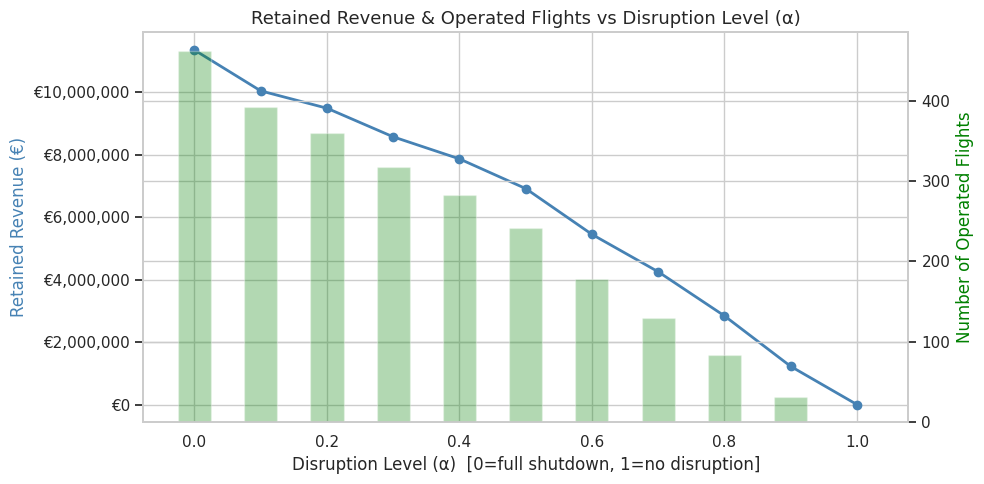

In [27]:


# Sensitivity analysis: alpha = 0.0 to 1.0
print("\n=== SENSITIVITY ANALYSIS ===")
results = []
for a in np.arange(0.0, 1.1, 0.1):
    results.append(execute(round(a, 1)))

results_df = pd.DataFrame(results)[['alpha', 'retained_revenue', 'n_operated', 'n_cancelled', 'solve_result']]
print("\nSensitivity Analysis Summary:")
print(results_df.to_string(index=False))

# ---------------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------------
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(results_df['alpha'], results_df['retained_revenue'],
         marker='o', color='steelblue', linewidth=2, label='Retained Revenue (€)')
ax1.set_xlabel('Disruption Level (α)  [0=full shutdown, 1=no disruption]', fontsize=12)
ax1.set_ylabel('Retained Revenue (€)', color='steelblue', fontsize=12)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€{x:,.0f}'))
ax2 = ax1.twinx()
ax2.bar(results_df['alpha'], results_df['n_operated'],
        width=0.05, alpha=0.3, color='green', label='Operated Flights')
ax2.set_ylabel('Number of Operated Flights', color='green', fontsize=12)
ax1.set_title('Retained Revenue & Operated Flights vs Disruption Level (α)', fontsize=13)
fig.tight_layout()
plt.show()

In [28]:
# =============================================================================
# EXTENSION: Incorporating Maintenance Costs into the Model
# =============================================================================

# Currently, the objective maximises retained revenue from operated flights:
#
#   Maximise:  sum {i in FLIGHTS} revenue[i] * operate[i]
#
# In reality, every flight that operates incurs a maintenance cost —
# wear and tear on the aircraft, engine checks, etc.
# To incorporate this, we need one new parameter and a modified objective.

# -----------------------------------------------------------------------------
# New Parameter
# -----------------------------------------------------------------------------
# maint_cost[i] = fixed maintenance cost of operating flight i (€)
#
# In AMPL this would be declared as:
#   param maint_cost {i in FLIGHTS} >= 0;
#
# This would be populated from the dataset or estimated per aircraft type:
#   ampl.param['maint_cost'] = flight_data['maint_cost'].to_dict()

# -----------------------------------------------------------------------------
# Modified Objective
# -----------------------------------------------------------------------------
# Instead of just rewarding operated flights for their revenue, we subtract
# the maintenance cost — so the solver only operates a flight if the
# revenue justifies the cost:
#
#   Maximise:  sum {i in FLIGHTS} (revenue[i] - maint_cost[i]) * operate[i]
#
# In AMPL this would be:
#   maximize NetBenefit:
#       sum {i in FLIGHTS} (revenue[i] - maint_cost[i]) * operate[i];

# -----------------------------------------------------------------------------
# No Constraints Change
# -----------------------------------------------------------------------------
# Only the objective is affected. All capacity and routing constraints
# remain identical to the base model.

# -----------------------------------------------------------------------------
# Practical Implication
# -----------------------------------------------------------------------------
# If maint_cost[i] > revenue[i] for a given flight, the solver will prefer
# to CANCEL that flight even if airport capacity allows it to operate.
# This allows the airline to prioritise high-margin flights during disruption
# recovery and willingly drop low-margin flights — reflecting real-world
# airline decision-making more accurately than revenue alone.